# Lab 13: Dictionaries 

A lot of this lab is explanation. It will take your through examples of code using dictionaries. Be sure to run the example code to understand how it works. You will need to write code to fix a KeyError in the letter frequency code, complete the word_count function in the Word Count section, and complete the main function in the Caesar cipher section. There is also an optional challenge question at the end.

The file `data/airports100.csv` contains a list of the first 100 three-letter airport codes. Open the file and take a look at the data. We can see that it has a header describing the columns in the file, followed by data for each airport, one airport per line:

```
City,AirportCode,AirportName,Country,CountryAbbrev
Aberdeen,APG,Phillips AAF,United States,US
Aberdeen,ABR,Municipal,United States,US
Abilene,DYS,Dyess AFB,United States,US
Abilene,ABI,Municipal,United States,US
Abingdon,VJI,Virginia Highlands,United States,US
Ada,ADT,Ada,United States,US
Adak Island,ADK,Adak Island Ns,United States,US
Adrian,ADG,Lenawee County,United States,US
Afton,AFO,Municipal,United States,US
```

We will create a dictionary that maps airport code to the name of the airport.

In [1]:
#When you run this cell, "nothing" will happen, but it needs to be run, so that the next few cells can produce output
def read_airport_file(filename):
    file = open(filename, 'r')
    line = file.readline()
    airports = {}
    for line in file:
        fields = line.split(',')
        code = fields[1]
        name = fields[2]
        airports[code] = name
    return airports

codes_map = read_airport_file('data/airports100.csv')

We can use the `in` keyword to see if a key is in a dictionary.

For example, what is the result of `'ORD' in codes_map`? `'AKC' in codes_map`?

What happens when you do `codes_map['ORD']`? `codes_map['AKC']`?

In [2]:
codes_map['AKC']

'Fulton International'

Dictionaries have a `keys()` function that returns a list of keys in the dictionary. What is `codes_map.keys()`?

In [3]:
codes_map.keys()

dict_keys(['APG', 'ABR', 'DYS', 'ABI', 'VJI', 'ADT', 'ADK', 'ADG', 'AFO', 'AIK', 'ANW', 'AKK', 'KKI', 'AKI', 'AKO', 'CAK', 'AKC', 'KQA', 'AUK', 'NGZ', 'HMN', 'ALM', 'ALS', 'NAB', 'ABY', 'ALB', 'CVO', 'AEL', 'ABQ', 'WKK', 'AED', 'ALX', 'AEX', 'ESF', 'AXN', 'AXB', 'AXG', 'ALI', 'AIV', 'ALZ', 'AET', 'AIA', 'AMN', 'APN', 'ALE', 'ALN', 'LTS', 'AXS', 'AQY', 'AMA', 'TDW', 'ABL', 'AHT', 'AHH', 'AMW', 'AYZ', 'AOS', 'OTS', 'NDV', 'ANA', 'AKP', 'EDF', 'ANC', 'MRI', 'AID', 'AND', 'ADR', 'AXX', 'ANQ', 'AGN', 'RFK', 'ANI', 'AIB', 'ARB', 'ANP', 'ANN', 'ANB', 'QAW', 'RLI', 'ANY', 'ATE', 'ANV', 'AAF', 'APV', 'ATW', 'AHF', 'ACV', 'ARC', 'AHD', 'ADM', 'JLH', 'ATS', 'ARX', 'ASX', 'ASY', 'ASE', 'AST', 'AHN', 'ATO', 'MMI'])

The `for` loop also treats dictionaries in a special way. If the `for` loop uses `in` with a dictionary, each iteration of the for loop will have the loop variable be a key in the dictionary (not necessarily in order!).

Try:
```
for code in codes_map:
  print(codes_map[code])
```

Now modify the loop to print the code, a colon, and then the airport name.

```
APG : Phillips AAF
ABR : Municipal
DYS : Dyess AFB
ABI : Municipal
VJI : Virginia Highlands
ADT : Ada
...
```

In [4]:
for code in codes_map:
    print(code, ':', codes_map[code])

APG : Phillips AAF
ABR : Municipal
DYS : Dyess AFB
ABI : Municipal
VJI : Virginia Highlands
ADT : Ada
ADK : Adak Island Ns
ADG : Lenawee County
AFO : Municipal
AIK : Municipal
ANW : Ainsworth
AKK : Akhiok SPB
KKI : Spb
AKI : Akiak
AKO : Colorado Plains Regional Airport
CAK : Akron/canton Regional
AKC : Fulton International
KQA : Akutan
AUK : Alakanuk
NGZ : NAS
HMN : Holloman AFB
ALM : Municipal
ALS : Municipal
NAB : Albany NAS
ABY : Dougherty County
ALB : Albany International
CVO : Albany
AEL : Albert Lea
ABQ : Albuquerque International
WKK : Aleknagik
AED : Aleneva
ALX : Thomas C Russell Fld
AEX : Alexandria International
ESF : Esler Field
AXN : Alexandria
AXB : Alexandria Bay
AXG : Algona
ALI : International
AIV : George Downer
ALZ : Alitak SPB
AET : Allakaket
AIA : Alliance
AMN : Gratiot Community
APN : Alpena County Regional
ALE : Alpine
ALN : Alton
LTS : Altus AFB
AXS : Municipal
AQY : Alyeska
AMA : Rick Husband Amarillo International
TDW : Tradewind
ABL : Ambler
AHT : Amchitka
AH

A common use of dictionaries are to generate histograms, or counts of occurrences of something. Let's count the occurrences of letters in a name.

To start, run the cell below. Note how you can index into strings just like lists. The following code declares a variables with my name, converts it to lower case, and then prints each letter.

In [5]:
name = 'Addison Leigh Schwamb'
name = name.lower()
for i in range(len(name)):
    letter = name[i]
    print(letter, end=' ')

a d d i s o n   l e i g h   s c h w a m b 

Now we will use a dictionary to keep track of the frequencies of letters. The frequencies dictionary will map a letter to an integer count. Here's a first try:

In [6]:
name = 'Addison Leigh Schwamb'
name = name.lower()
frequencies = {}
for i in range(len(name)):
    letter = name[i]
    frequencies[letter] = frequencies[letter] + 1

KeyError: 'a'

Note how the code had an error! The error was a `KeyError`, indicating that a key was not in the dictionary. When we try to read a key that doesn't exist, this is an error. Modify the code so that it first checks to see whether the key exists, and if it doesn't, gives it an initial value.

In [8]:
#FIX THIS CODE!

name = 'Addison Leigh Schwamb'
name = name.lower()
frequencies = {}
for i in range(len(name)):
    letter = name[i]
    if letter in frequencies:
        frequencies[letter] = frequencies[letter] + 1
    else:
        frequencies[letter] = 1
print(frequencies)

{'a': 2, 'd': 2, 'i': 2, 's': 2, 'o': 1, 'n': 1, ' ': 2, 'l': 1, 'e': 1, 'g': 1, 'h': 2, 'c': 1, 'w': 1, 'm': 1, 'b': 1}


## Word Count

In the following exercises, we'll write functions that will tell us the distributions of words in some classic western literature.

If you look in the `data` folder, there are several `pg-` files. If you open one, you'll find it's an ebook downloaded from [Project Gutenberg](https://www.gutenberg.org/).

Our goal will be to find the most frequently occurring words in a given text.

First, we'll start off by introducing a function to clean up a word. This is similar to how we saw it in class, but uses a built-in function and will handle all punctuation. Words that we read from the files may have punctuation, or may be capitalized or not. The following function changes a word to lowercase and gets rid of all punctuation.

In [11]:
from string import punctuation

#This function removes punctuation and changes s to it's lowercase version
#Parameters: s, a string
#Returns: a cleaned up version of s
def clean_string(s):
    s = s.lower()
    s = s.translate(str.maketrans('', '', punctuation))
    return s

clean = clean_string(',A(ddI)_sOn.')
print(clean)




addison


Now, we'll write a function to read the file and create a dictionary that maps words to the count of occurrences of that word.

We'll do this like we would reading any other file, line by line. However, for each line, we will need to split the line into individual words, we'll do this by splitting on whitespace.

For an individual line, we can get a list of words on that line by calling:
`words = line.split()`. `words` is a list of strings, one for each word.

The entire algorithm will be:
1. Create an empty dictionary.
1. Open the file given by filename.
1. Read the file, line by line.
1. For each line:
   1. Split the line into words.
   1. For each word, add one to its entry in the dictionary.

In [12]:
def word_count(filename):
    word_counts = {}
    file = open(filename, 'r')
    for line in file:
        line = line.rstrip()
        #Need to call the clean_string function to clean up any punctuation in the string.
        line = clean_string(line)
        words = line.split()
        for i in range(len(words)):
            word = words[i]
            if word in word_counts:
                word_counts[word] += 1
            else:
                word_counts[word] = 1
    file.close()
    return word_counts

grimm_counts = word_count('data/pg-grimm.txt')
print(grimm_counts['princess']) # prints 101
print(grimm_counts['prince']) # prints 63

101
63


In [13]:
holmes_counts = word_count('data/pg-sherlock_holmes.txt')
print(holmes_counts['sherlock']) # prints 102
print(holmes_counts['holmes']) # prints 463

102
463


## Caesar Cipher
A Caesar Cipher is a type of substitution cipher in which each letter in the plaintext is replaced by a letter some fixed number of positions down the alphabet. This cipher are named after Julius Caesar, who used it in his private correspondence.

### Example of a Caesar Cipher
```
Plain:  ABCDEFGHIJKLMNOPQRSTUVWXYZ 
Cipher: XYZABCDEFGHIJKLMNOPQRSTUVW
```
* Transformation can be represented by aligning two alphabets.
* This one uses a left rotation of three places, equivalent to a right shift of 23

### Encrypting of a Message
```
Ciphertext: QEB NRFZH YOLTK CLU GRJMP LSBO QEB IXWV ALD
Plaintext:  the quick brown fox jumps over the lazy dog
```
* Look up each letter of the message in the "plain" line and write down the corresponding letter in the "cipher" line.
* The encryption can also be represented using modular arithmetic
* Transform the letters into numbers, according to the scheme, A = 0, B = 1,..., Z = 25. 
* Encryption of a letter by a shift $n$ can be described mathematically as,
$𝐸_𝑛(𝑥)=(𝑥+𝑛)\ \%\ 26$
* In the above equation, $x$ is the index of the letter in the original alphabet

In [14]:
# This function encrypts a text message by shifting all letters by n
# Parameters: text - a string, n - an integer between 0 and 26
# Returns: cipher - the encrypted message
def encode(text, n):
    text = text.lower()
    alphabet = 'abcdefghijklmnopqrstuvwxyz'
  
    cipher = ''
    for i in range(0, len(text)):
        ch = text[i]
        if ch in alphabet:
            cipher += alphabet[(alphabet.index(ch) + n) % 26]
        else:
            cipher += ch
    return cipher

encode("the quick brown fox jumps over the lazy dog", 3)

'wkh txlfn eurzq ira mxpsv ryhu wkh odcb grj'

### Decrypting of a message
* Opposite process of encryption
* Look up each letter of the message in the "cipher" line and write down the corresponding letter in the "plain" line.
* Can also use modular arithmetic to solve $D_𝑛(𝑥)=(𝑥−𝑛)\ \%\ 26$

In [15]:
def decode(cipher, n):
    cipher = cipher.lower()
    alphabet = 'abcdefghijklmnopqrstuvwxyz'
  
    text = ''
    for i in range(0, len(cipher)):
        ch = cipher[i]
        if ch in alphabet:
            text += alphabet[(alphabet.index(ch) - n) % 26]
        else:
            text += ch
    return text

decode('wkh txlfn eurzq ira mxpsv ryhu wkh odcb grj', 3)

'the quick brown fox jumps over the lazy dog'

### Breaking the Code
If you were not the intended recipient of the message, you wouldn't be told the shift ($n$).

To determine what $n$ is:
1. Analyze the frequency of each character in the encrypted message
2. Since 'E' is the most common letter used in English, you should find the shift from E to the most common letter in the message


__What you need to do__:
* Write a Caesar cipher program to decode the message in cipherText.txt
* You will need to read in the file (you can read it in all as 1 line if you’d like).
* Get the frequency count for each letter (don't include spaces).
* Find the shift between the max letter and 'e'
* Use the shift to decode the message


Unable to revert mtime: /Library/Fonts
Matplotlib is building the font cache; this may take a moment.


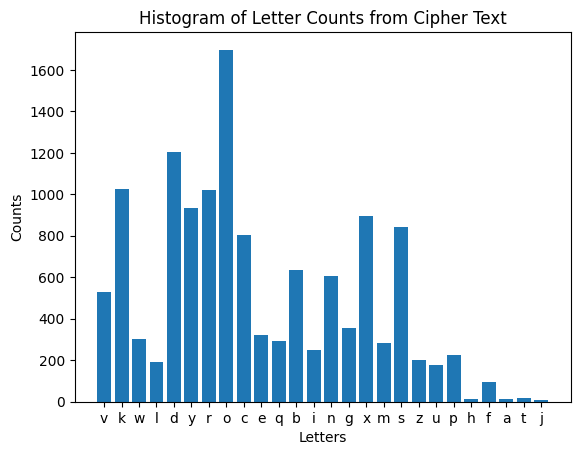

o 1697
lamb to the slaughter  by roald dahl   the room was warm and clean the curtains drawn the two table lamps alight  hers and the one by the empty chair opposite on the sideboard behind her two tall glasses soda water whiskey  fresh ice cubes in the thermos bucket  mary maloney was waiting for her husband to come him from work  now and again she would glance up at the clock but without anxiety merely to please herself with the thought that each minute gone by made it nearer the time when he would come  there was a slow smiling air about her and about everything she did  the drop of a head as she bent over her sewing was curiously tranquil  her skin  for this was her sixth month with child  had acquired a wonderful translucent quality the mouth was soft and the eyes with their new placid look seemed larger darker than before when the clock said ten minutes to five she began to listen and a few moments later punctually as always she heard the tires on the gravel outside and the car d

In [16]:
import matplotlib.pyplot as plt

def decode(cipher, n):
    cipher = cipher.lower()
    alphabet = 'abcdefghijklmnopqrstuvwxyz'
  
    text = ''
    for i in range(0, len(cipher)):
        ch = cipher[i]
        if ch in alphabet:
            text += alphabet[(alphabet.index(ch) - n) % 26]
        else:
            text += ch
    return text

def main():

    file = open('data/cipherText.txt', 'r')
    
    #Need to keep track of the counts of all the letters in the encrypted message
    letterCnts = {}
    #Need to add together all the lines from the encrypted message, so you can 
    #pass the entire encrypted string into the decode function.
    text = ''
  
    for line in file:
        line = line.rstrip()
        text += line
        for i in range(len(line)):
            ch = line[i]
            if ch.isalpha():
                if ch in letterCnts:
                    letterCnts[ch] += 1
                else:
                    letterCnts[ch] = 1
    file.close()
    
    #This next section is just to show you how you could use a dictionary to draw a histogram
    #You did not need to plot the counts like this. 

    # Extract keys and values from the dictionary
    keys = list(letterCnts.keys())
    values = list(letterCnts.values())

    # Create the histogram
    plt.bar(keys, values)
    plt.xlabel('Letters')
    plt.ylabel('Counts')
    plt.title('Histogram of Letter Counts from Cipher Text')
    plt.show()
    
    #From here down you should have included in your solution something similar
  
    #Find the max letter in the letterCnts dictionary
    maxLetter = ''
    maxLetterCnt = 0
    for key in letterCnts:
        if letterCnts[key] > maxLetterCnt:
            maxLetterCnt = letterCnts[key]
            maxLetter = key
    print(maxLetter, maxLetterCnt)
  
    #Need to determine the difference between e and the max letter index
    alphabet = 'abcdefghijklmnopqrstuvwxyz'
    #Find the index of the max letter in the alphabet
    maxLetterInd = alphabet.index(maxLetter)
    #Compare the index of the max letter to the index of e to get the shift
    shift = maxLetterInd - alphabet.index('e')
  
    #Call the decode function with the entire encrypted message and the shift that you just found
    text = decode(text, shift)
    print(text)
 
  
  
main()

__Challenge:__(optional) Write a function that takes two dictionaries d1 and d2 and returns a dictionary of word counts (key = word, value = count), but only for words in d1 but _not_ in d2.

In [17]:
# This function takes in two dictionaries d1 and d2 and returns a dictionary of word counts 
# (key = word, value = count), but only for words in d1 but not in d2.
def unique(d1, d2):
    counts = {}
    for key in d1:
        if key not in d2:
            counts[key] = d1[key]
    return counts

unique({'the': 7221, 'project': 88, 'gutenberg': 29, 'ebook': 10, 'of': 1488, 'by': 316, 'this': 375, 'is': 492, 'for': 772,},
       {'the': 1009, 'of': 988, 'by': 316, 'this': 375, 'is': 492, 'for': 772, 'at': 635, 'no': 321, 'and': 5546})

{'project': 88, 'gutenberg': 29, 'ebook': 10}